In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model
from statsmodels.tsa.stattools import acf, coint
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import src.data as data
import src.indicators as indicators
import src.strategies as strategies
import src.plots as plots
from src.backtesting_engine import bactester, compute_buy_hold_benchmark

# Data

In [2]:
btc = data.load_ohlcv("BTC/USDT")
eth = data.load_ohlcv("ETH/USDT")

In [3]:
btc , btc_invals  = data.clean_and_validate_crypto(btc, ticker_label="BTC-USD")
eth , eth_invals  = data.clean_and_validate_crypto(eth, ticker_label="ETH-USD")

=== Data Cleaning Report: BTC-USD ===
Zero-Volume Bars Found:     0
Invalid OHLC Bars Found:    0
------------------------------------------
=== Data Cleaning Report: ETH-USD ===
Zero-Volume Bars Found:     0
Invalid OHLC Bars Found:    0
------------------------------------------


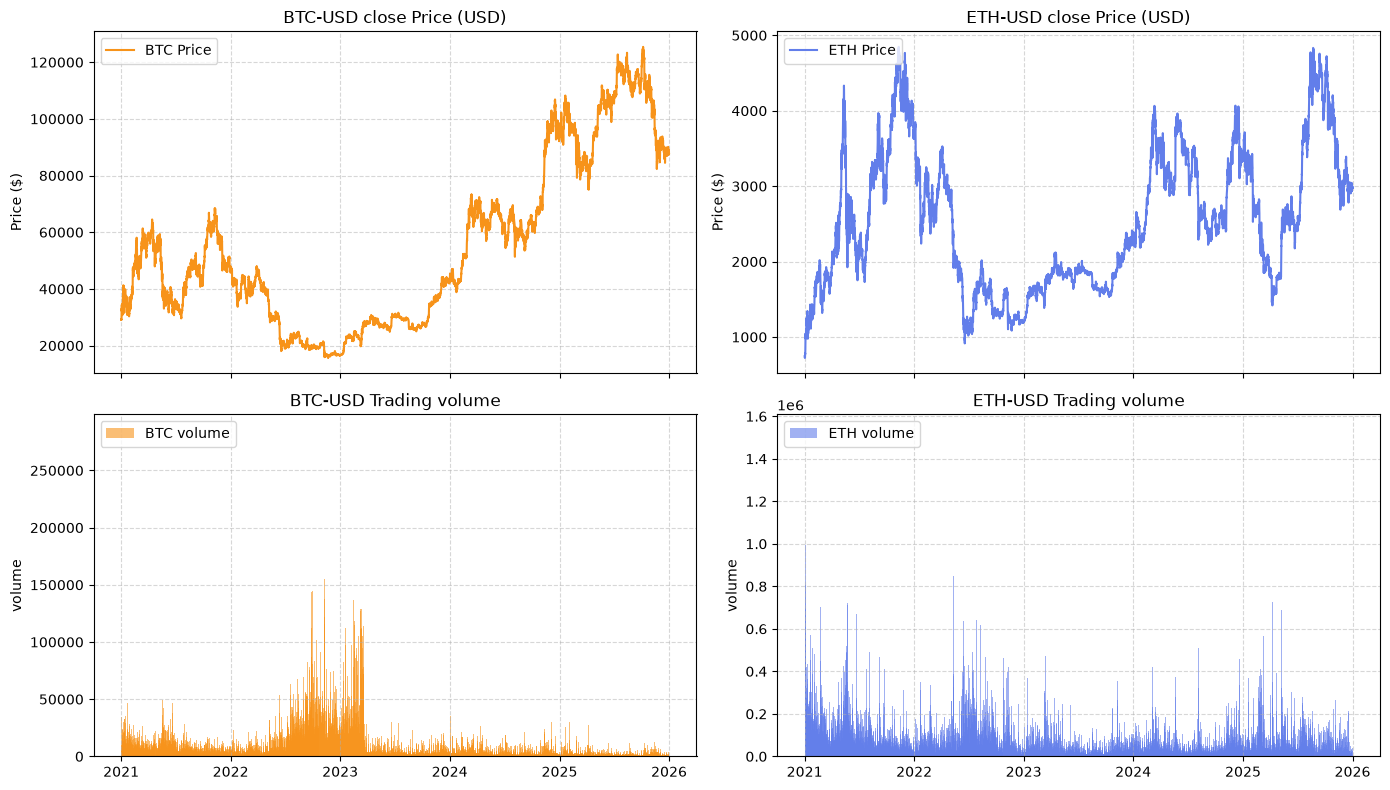

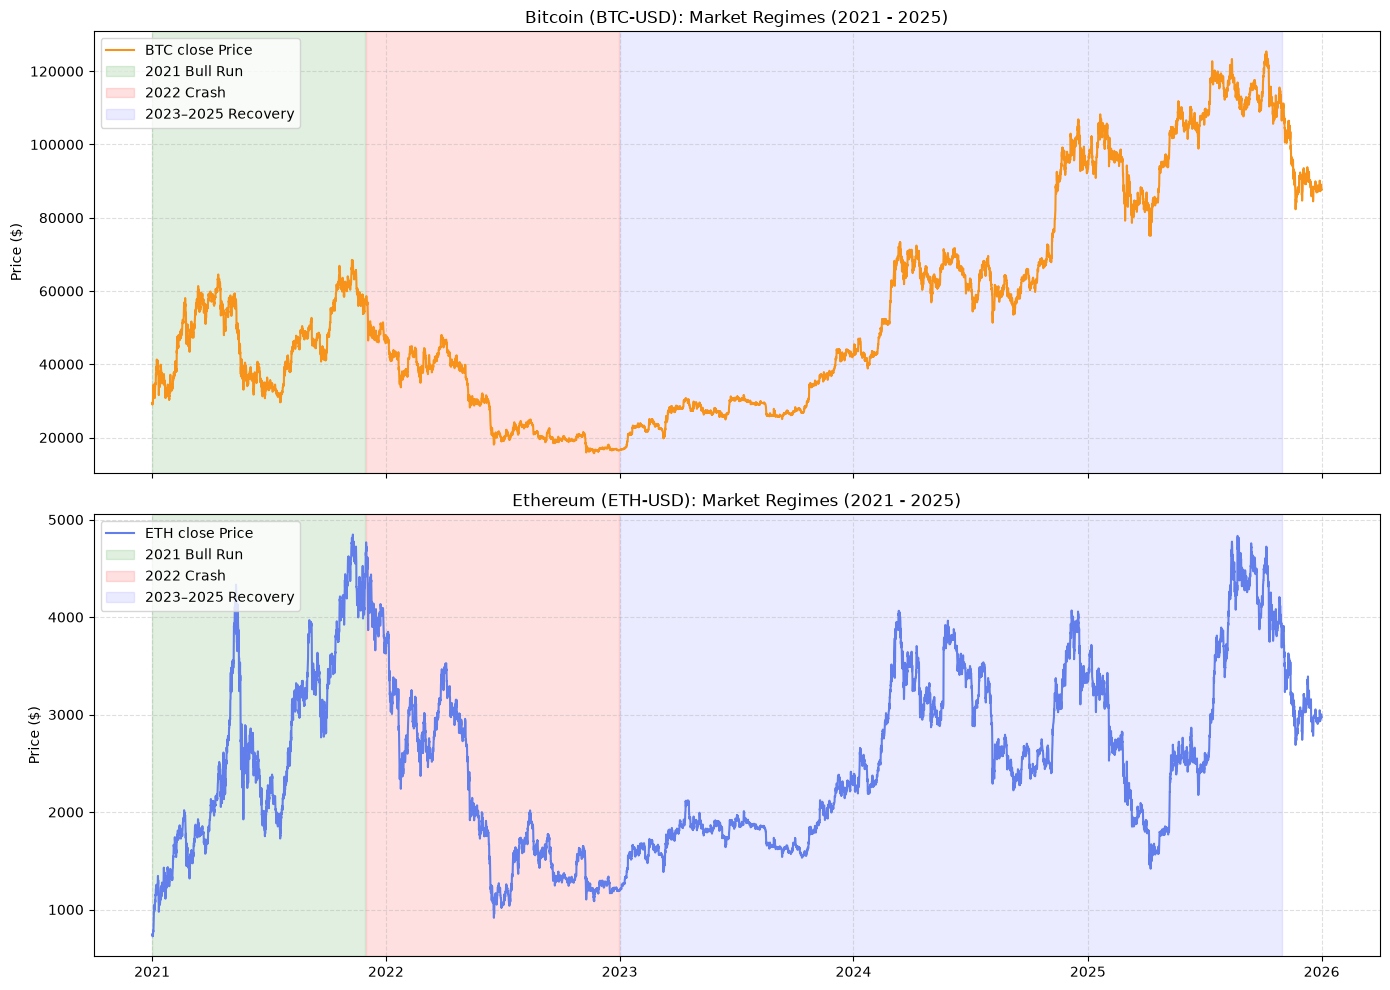

In [4]:
plots.plot_price_volume(btc, eth)
plots.plot_regimes(btc, eth)

In [5]:
btc_23 = btc.loc[:"2023-12-31"]
eth_23 = eth.loc[:"2023-12-31"]

assets = {"BTC": btc_23, "ETH": eth_23}

start_capital = 100000.00
periods = 6*365

# Benchmark

In [6]:
results = {}

for name, df in assets.items():
    results[("buy_hold", name)] = compute_buy_hold_benchmark(df, periods=periods, start_capital=start_capital)

# Metrics

Return autocorrelation

BTC 0.024674440339920178
[ 1.         -0.03390664  0.01630509  0.04024496 -0.0179592  -0.01003808
 -0.05096689 -0.00606296  0.01577775 -0.00740697  0.01492862  0.01653046
 -0.02213346  0.00354851  0.00231153  0.02172714  0.00397713  0.00339946
 -0.0031302  -0.04264947  0.00651961 -0.00623514 -0.00381675  0.03205489
 -0.01789725  0.01461751  0.03628294 -0.00344575  0.0026603   0.00780263
  0.02010858 -0.00330371 -0.0254616  -0.0179692   0.0211089   0.03228754
 -0.00271292 -0.01597153  0.01862147]


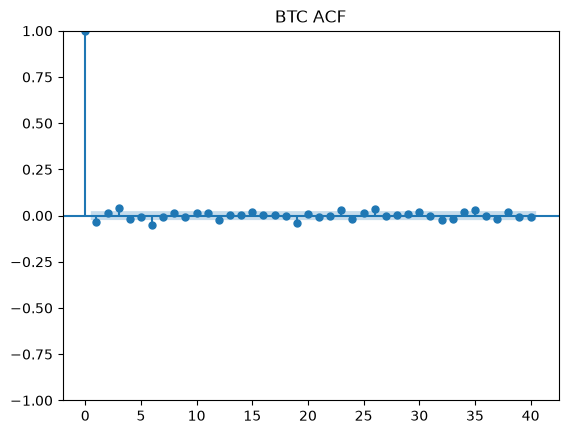

ETH 0.024674440339920178
[ 1.         -0.03833721  0.03035041  0.0249928  -0.01823611 -0.00240865
 -0.04502311 -0.01101632  0.00218998  0.01057593  0.0166656   0.03389069
 -0.0020049  -0.00971538  0.00458132  0.00133941  0.00238359  0.01056624
  0.00445075 -0.03852453  0.01101914  0.01247268  0.00777758  0.02477217
 -0.0286831   0.00763388  0.0196634  -0.02229111 -0.00912228  0.01493963
  0.00172932 -0.02109509 -0.02196759  0.00271048  0.04146411  0.02175638
  0.03783567 -0.02858552  0.02902949]


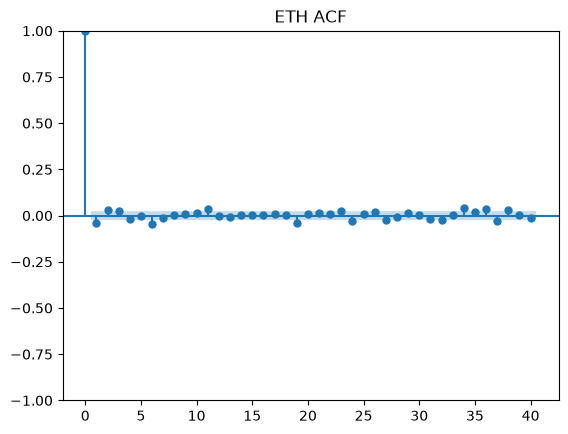

In [7]:
lag_window = 50

for name, df in assets.items():
    returns = df.close.pct_change().dropna()
    print(name, 2/np.sqrt(len(df)))
    print(acf(returns, lag_window))
    plot_acf(returns, lags=40, title=f"{name} ACF")
    plt.show()

Variance ratio

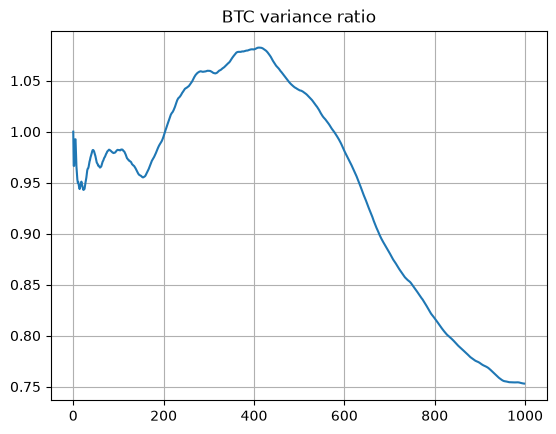

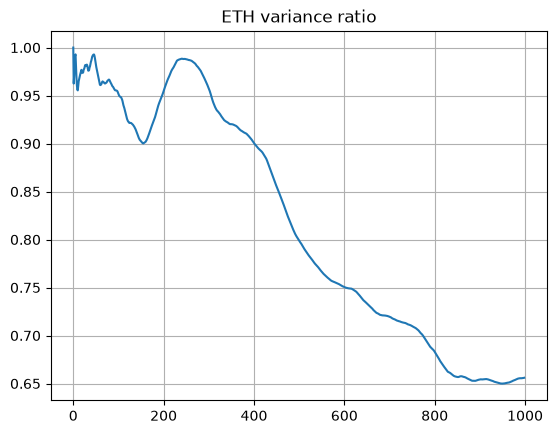

In [8]:
for name, df in assets.items():
    var_ratio = [indicators.variance_ratio(df, win) for win in range(1,1000)]
    plt.grid(True)
    plt.plot(var_ratio)
    plt.title(f"{name} variance ratio")
    plt.show()

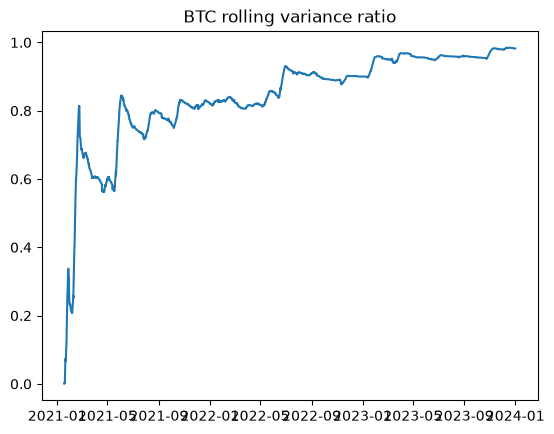

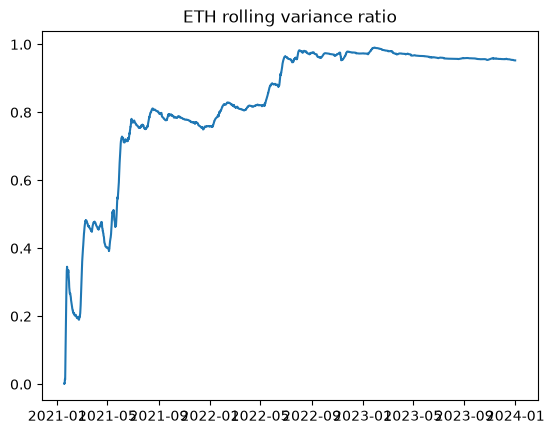

In [9]:
for name, df in assets.items():
    rollingvr = indicators.rolling_vr(df, 100)
    plt.plot(rollingvr)
    plt.title(f"{name} rolling variance ratio")
    plt.show()

ADX

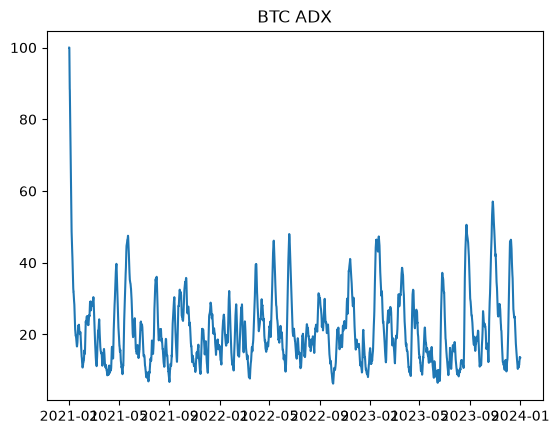

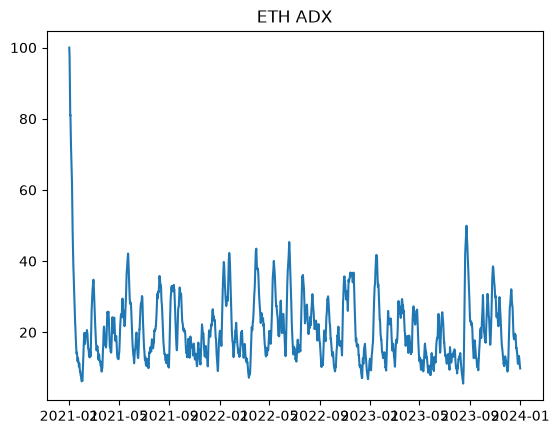

In [10]:
for name, df in assets.items():
    plt.plot(indicators.adx(df, 30).adx)
    plt.title(f"{name} ADX")
    plt.show()

# Models

Mean reversion, MA crossover

In [11]:
models = {
    "mean_reversion": strategies.mean_reversion,
    "ma_crossover": strategies.ma_crossover,
    "ma_crossover_v2": strategies.ma_crossover_better,
    "ma_cross_long": strategies.ma_cross_long,
}

params = {
    "mean_reversion": {
        "BTC": {
            "window": 14,
            "entry": 2.0,
            "exit": 0.0,
            "stoploss": 4.0,
        },
        "ETH": {
            "window": 14,
            "entry": 2.0,
            "exit": 0.0,
            "stoploss": 4.0,
        },
    },
    "ma_crossover": {
        "BTC": {
            "fast": 30,
            "slow": 90,
        },
        "ETH": {
            "fast": 30,
            "slow": 90,
        },
    },
    "ma_crossover_v2": {
        "BTC": {
            "fast": 50,
            "slow": 200,
            "atr_period": 25,
            "atr_k": 5.5,
        },
        "ETH": {
            "fast": 60,
            "slow": 230,
            "atr_period": 14,
            "atr_k": 6,
        },
    },
    "ma_cross_long": {
        "BTC": {
            "fast": 40,
            "slow": 200,
            "atr_period": 20,
            "atr_k": 7,
            "adx_min": 25,
            "cooldown": 7,
        },
        "ETH": {
            "fast": 60,
            "slow": 230,
            "atr_period": 14,
            "atr_k": 6,
            "adx_min": 25,
            "cooldown": 6,
        },
    },
}

for model_name, model in models.items():
    for name, df in assets.items():
        kw = params.get(model_name, {}).get(name, {})
        results[(model_name, name)] = bactester(df, signals=model(df, **kw), start_capital=start_capital, periods=periods)

Random signals

In [12]:
rng = np.random.default_rng(42)

for name, df in assets.items():
    signals = pd.Series(rng.choice([0, -1, 1], size=len(df)), index=df.index)
    results[("random", name)] = bactester(df, signals, start_capital, periods)

# Results

In [13]:
keys = [
    "gross_profit", "gross_loss", "net_profit", "total_return", "buy_hold_return",
    "total_trades", "win_rate", "avg_win", "avg_loss", "largest_win", "largest_loss",
    "avg_holding_days", "max_holding_days", "max_drawdown", "sharpe", "sortino",
]

pd.DataFrame({k: {m: r[m] for m in keys} for k, r in results.items()}).T.round(3)

gross_profit  gross_loss  net_profit  total_return  \
buy_hold        BTC     43984.377       0.000   43984.377         0.440   
                ETH    205444.284       0.000  205444.284         2.054   
mean_reversion  BTC    174251.571 -258119.900  -83868.329        -0.839   
                ETH    294120.511 -374226.580  -80106.068        -0.801   
ma_crossover    BTC    169070.622 -216549.646  -47479.025        -0.475   
                ETH    549683.186 -538964.946   10718.240         0.107   
ma_crossover_v2 BTC    294733.844 -311358.958  -16625.114        -0.166   
                ETH    661885.521 -643956.806   17928.715         0.179   
ma_cross_long   BTC    231099.855 -137241.845   93858.010         0.939   
                ETH    398420.559 -246784.938  151635.622         1.516   
random          BTC    148905.470 -248899.505  -99994.036        -1.000   
                ETH    250016.227 -350002.044  -99985.818        -1.000   

                     buy_hold_return  total_trades  win_rate     avg_win  \
buy_hold        BTC            0.440           1.0     1.000   43984.377   
                ETH            2.054           1.0     1.000  205444.284   
mean_reversion  BTC            0.440         558.0     0.437     714.146   
                ETH            2.054         559.0     0.460    1144.438   
ma_crossover    BTC            0.440         158.0     0.367    2915.011   
                ETH            2.054         158.0     0.386    9011.200   
ma_crossover_v2 BTC            0.440          83.0     0.410    8668.642   
                ETH            2.054          64.0     0.391   26475.421   
ma_cross_long   BTC            0.440          34.0     0.353   19258.321   
                ETH            2.054          38.0     0.447   23436.503   
random          BTC            0.440        2907.0     0.347     147.724   
                ETH            2.054        2922.0     0.377     227.081   

                      avg_loss  largest_win  largest_loss  avg_holding_days  \
buy_hold        BTC      0.000    43984.377         0.000          1095.000   
                ETH      0.000   205444.284         0.000          1095.000   
mean_reversion  BTC   -822.038    14945.109    -10987.555             0.269   
                ETH  -1239.161    11001.026    -11619.494             0.286   
ma_crossover    BTC  -2165.496    16256.687     -9268.664             3.431   
                ETH  -5556.340    51802.320    -41932.217             3.384   
ma_crossover_v2 BTC  -6354.264    34765.515    -18488.184            11.847   
                ETH -16511.713   156424.669    -47715.850            15.357   
ma_cross_long   BTC  -6238.266    70476.948    -18227.018            13.745   
                ETH -11751.664    64584.046    -35224.906            12.583   
random          BTC   -131.069     6438.768    -12640.526             0.247   
                ETH   -192.203     8187.928    -16786.651             0.249   

                     max_holding_days  max_drawdown  sharpe  sortino  
buy_hold        BTC          1095.000        -0.770   0.514    0.735  
                ETH          1095.000        -0.811   0.864    1.234  
mean_reversion  BTC             1.333        -0.886  -2.151   -2.901  
                ETH             1.167        -0.860  -1.389   -1.929  
ma_crossover    BTC            20.333        -0.652  -0.196   -0.280  
                ETH            22.167        -0.690   0.373    0.534  
ma_crossover_v2 BTC            39.500        -0.666   0.200    0.287  
                ETH            73.333        -0.789   0.461    0.651  
ma_cross_long   BTC            59.167        -0.538   0.774    1.144  
                ETH            41.000        -0.578   0.852    1.224  
random          BTC             1.333        -1.000  -5.802   -7.570  
                ETH             1.333        -1.000  -3.926   -5.285

Equity curves

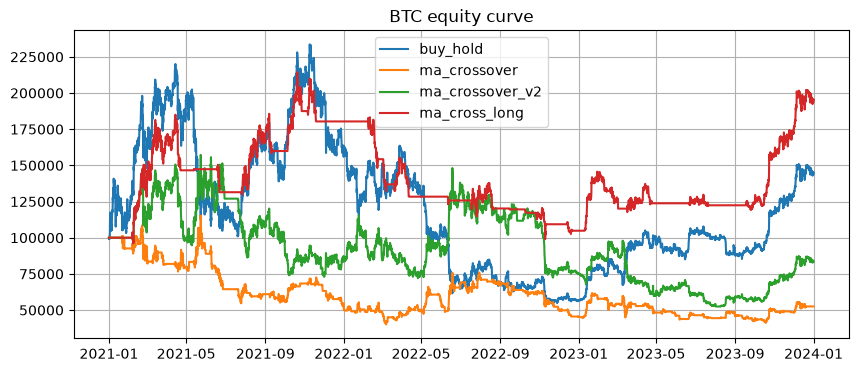

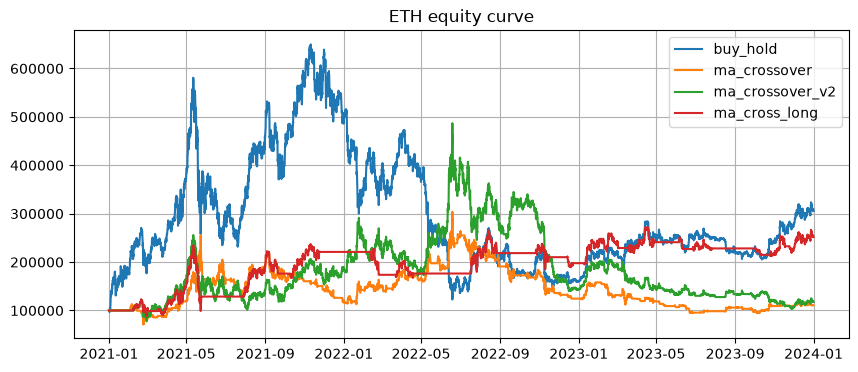

In [14]:
plots.plot_equity(results, ["buy_hold", "ma_crossover", "ma_crossover_v2", "ma_cross_long"], assets)

# Statistical models

GARCH volatility sizing

Test: raw returns (constant mean) vs squared returns (ARCH effect)

In [15]:
for name, df in assets.items():
    returns = np.log(df.close).diff().dropna()
    print(name, "95% band", round(2 / np.sqrt(len(returns)), 3))
    print(name, "raw     ", np.round(acf(returns, nlags=15)[1:], 3))
    print(name, "squared ", np.round(acf(returns ** 2, nlags=15)[1:], 3))

BTC 95% band 0.025
BTC raw      [-0.034  0.017  0.041 -0.018 -0.01  -0.051 -0.006  0.015 -0.007  0.016
  0.018 -0.021  0.004  0.003  0.022]
BTC squared  [0.119 0.199 0.106 0.107 0.135 0.08  0.076 0.075 0.068 0.092 0.083 0.099
 0.06  0.076 0.082]
ETH 95% band 0.025
ETH raw      [-0.038  0.031  0.026 -0.018 -0.002 -0.046 -0.01   0.002  0.011  0.017
  0.035 -0.001 -0.009  0.006  0.003]
ETH squared  [0.198 0.226 0.215 0.191 0.222 0.154 0.191 0.147 0.151 0.134 0.176 0.161
 0.155 0.143 0.133]


GARCH(1,1) fit and Ljung-Box on squared standardized residuals

In [16]:
for name, df in assets.items():
    returns = np.log(df.close).diff().dropna() * 100
    garch_result = arch_model(returns, mean='Constant', vol='Garch', p=1, q=1, dist='t').fit(disp='off')
    print(name)
    print(garch_result.summary())
    print(acorr_ljungbox(garch_result.std_resid ** 2, lags=[10, 20]))

BTC
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9718.71
Distribution:      Standardized Student's t   AIC:                           19447.4
Method:                  Maximum Likelihood   BIC:                           19481.4
                                              No. Observations:                 6569
Date:                      Thu, Oct 08 2026   Df Residuals:                     6568
Time:                              19:12:00   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
---------------------------------------------------------------------------

Forecast volatility vs realised absolute return

In [17]:
for name, df in assets.items():
    for label, fn in [("garch", strategies.garch_sigma), ("garch_v2", strategies.garch_sigma_v2)]:
        sig = fn(df).dropna()
        ab = np.log(df.close).diff().abs().loc[sig.index]
        print(name, label, sig.corr(ab))
        print(ab.groupby(pd.qcut(sig, 5), observed=True).mean())

BTC garch 0.20285329121897605
(0.00262, 0.00652]    0.003858
(0.00652, 0.00757]    0.004821
(0.00757, 0.00879]    0.005280
(0.00879, 0.0106]     0.005617
(0.0106, 0.0235]      0.007752
Name: close, dtype: float64
BTC garch_v2 0.20149622269151746
(0.00262, 0.00679]    0.003793
(0.00679, 0.0078]     0.004896
(0.0078, 0.00894]     0.005277
(0.00894, 0.0108]     0.005643
(0.0108, 0.0235]      0.007719
Name: close, dtype: float64
ETH garch 0.20268228199687535
(0.0032300000000000002, 0.00715]    0.003724
(0.00715, 0.00883]                  0.005577
(0.00883, 0.0104]                   0.006695
(0.0104, 0.0124]                    0.006735
(0.0124, 0.0232]                    0.008228
Name: close, dtype: float64
ETH garch_v2 0.1996336672801605
(0.00387, 0.00747]    0.003960
(0.00747, 0.00902]    0.005366
(0.00902, 0.0105]     0.006669
(0.0105, 0.0125]      0.006656
(0.0125, 0.0232]      0.008308
Name: close, dtype: float64


Model: ma_cross_long with GARCH sizing, tested from 2023

Note: GARCH size is NaN before `test_start` and is filled with 0, so the garch strategies hold no position before 2023. Slicing is done from `start` before backtesting.

In [18]:
start = '2023-01-01'
garch_models = [
    ("plain", strategies.ma_cross_long),
    ("garch", strategies.ma_cross_long_garch),
    ("garch_v2", strategies.ma_cross_long_garch_v2),
]
cmp = {}

for name, df in assets.items():
    kw = params["ma_cross_long"][name]
    d = df.loc[start:]
    cmp[("buy_hold", name)] = compute_buy_hold_benchmark(d, periods=periods, start_capital=start_capital)
    for label, fn in garch_models:
        cmp[(label, name)] = bactester(d, fn(df, **kw).loc[start:], start_capital=start_capital, periods=periods)

pd.DataFrame({k: {m: r[m] for m in keys} for k, r in cmp.items()}).T.round(3)

,,gross_profit,gross_loss,net_profit,total_return,buy_hold_return,total_trades,win_rate,avg_win,avg_loss,largest_win,largest_loss,avg_holding_days,max_holding_days,max_drawdown,sharpe,sortino
buy_hold,BTC,154982.278,0.000,154982.278,1.550,1.550,1.0,1.000,154982.278,0.000,154982.278,0.000,365.000,365.000,-0.212,2.438,3.730
plain,BTC,102402.674,-17487.579,84915.095,0.849,1.550,9.0,0.444,25600.668,-3497.516,67225.757,-11694.372,24.019,59.167,-0.192,2.099,3.188
garch,BTC,98909.794,-17437.445,81472.348,0.815,1.550,9.0,0.444,24727.448,-3487.489,65974.149,-11747.406,24.019,59.167,-0.196,2.071,3.131
garch_v2,BTC,101270.471,-33503.523,67766.948,0.678,1.550,18.0,0.500,11252.275,-3722.614,26503.279,-11964.976,10.963,31.000,-0.231,1.901,2.864
buy_hold,ETH,90530.477,0.000,90530.477,0.905,0.905,1.0,1.000,90530.477,0.000,90530.477,0.000,365.000,365.000,-0.277,1.643,2.460
plain,ETH,58706.387,-31462.619,27243.768,0.272,0.905,16.0,0.438,8386.627,-3495.847,15350.065,-6884.768,12.083,31.833,-0.218,0.841,1.234
garch,ETH,59259.775,-31572.325,27687.450,0.277,0.905,16.0,0.438,8465.682,-3508.036,15752.276,-6908.775,12.083,31.833,-0.218,0.851,1.249
garch_v2,ETH,72877.867,-50068.769,22809.099,0.228,0.905,24.0,0.375,8097.541,-3337.918,15752.276,-7877.047,7.250,31.333,-0.267,0.767,1.126


In [19]:
for name, df in assets.items():
    for label, fn in [("garch", strategies.garch_size), ("garch_v2", strategies.garch_size_v2)]:
        s = fn(df).loc['2023':]
        print(name, label, s.value_counts(normalize=True).sort_index())

BTC garch 0.50    0.002740
0.75    0.035616
1.00    0.961644
Name: proportion, dtype: float64
BTC garch_v2 0.50    0.002740
0.75    0.036530
1.00    0.960731
Name: proportion, dtype: float64
ETH garch 0.75    0.005936
1.00    0.994064
Name: proportion, dtype: float64
ETH garch_v2 0.75    0.005936
1.00    0.994064
Name: proportion, dtype: float64


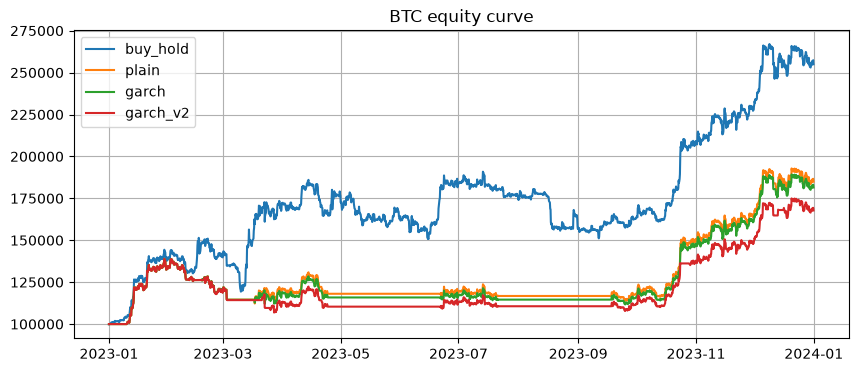

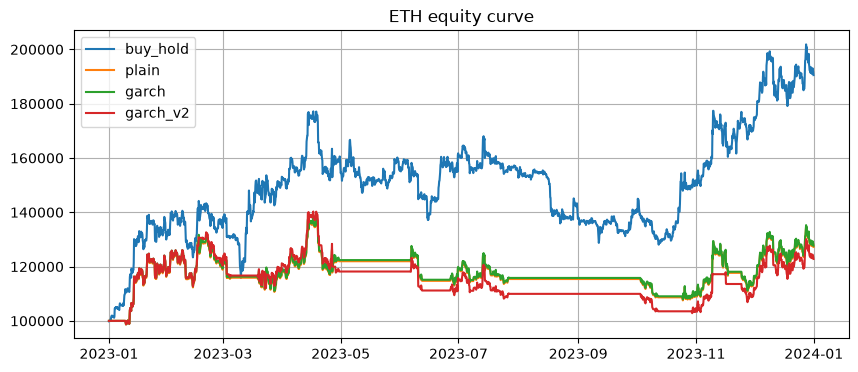

In [20]:
plots.plot_equity(cmp, ["buy_hold", "plain", "garch", "garch_v2"], assets)

Cointegration: ETH/BTC pairs

Test: return correlation and Engle-Granger (ETH on BTC, daily log prices)

In [21]:
pair = pd.concat([btc_23.close, eth_23.close], axis=1, keys=["btc", "eth"]).dropna()
px = np.log(pair.resample("1D").last().dropna())

ret = np.log(pair).diff()
print("return corr:", ret.btc.corr(ret.eth))


def half_life(x):
    lag = x.shift(1).dropna()
    d = x.diff().dropna()
    b = sm.OLS(d, sm.add_constant(lag)).fit().params.iloc[1]
    return -np.log(2) / np.log(1 + b) if -1 < b < 0 else np.inf


samples = {
    "full": px,
    "2021-06+": px.loc["2021-06-01":],
    "2022": px.loc["2022"],
    "2023": px.loc["2023"],
}

rows = {}
for k, p in samples.items():
    stat, pval, crit = coint(p.eth, p.btc, trend="c")
    ols = sm.OLS(p.eth, sm.add_constant(p.btc)).fit()
    rows[k] = {"n_days": len(p), "beta": ols.params["btc"], "eg_stat": stat, "eg_p": pval,
               "crit_5%": crit[1], "half_life_days": half_life(ols.resid)}

pd.DataFrame(rows).T.round(3)

return corr: 0.8487242068213674


,n_days,beta,eg_stat,eg_p,crit_5%,half_life_days
full,1095.0,0.805,-3.305,0.054,-3.342,42.905
2021-06+,944.0,0.999,-2.449,0.302,-3.343,48.353
2022,365.0,1.031,-2.151,0.450,-3.353,28.601
2023,365.0,0.563,-2.882,0.141,-3.353,12.747


Model: z-score reversion on the ETH/BTC spread, gated by a rolling Engle-Granger test (p < 0.10), tested from 2022

In [22]:
pairs_gates = [("gate", 0.10), ("no_gate", 1.01)]
pairs_cmp = {}

for label, p_max in pairs_gates:
    fit = strategies.pairs_fit(eth_23, btc_23, p_max=p_max)
    sig = strategies.pairs_reversion(eth_23, btc_23, fit=fit)
    spread = strategies.pairs_spread(eth_23, btc_23, fit[1])
    print(label, "gate on:", fit[2].loc['2022-01-01':].mean())

    for period, a, b in [("all", '2022-01-01', '2023-12-31'), ("2022", '2022-01-01', '2022-12-31'), ("2023", '2023-01-01', '2023-12-31')]:
        pairs_cmp[(label, period)] = bactester(spread.loc[a:b], sig.loc[a:b], start_capital=start_capital, periods=periods)

pd.DataFrame({k: {m: r[m] for m in keys} for k, r in pairs_cmp.items()}).T.round(3)

gate gate on: 0.2465753424657534
no_gate gate on: 1.0


gross_profit  gross_loss  net_profit  total_return  \
gate    all       3175.261       0.000    3175.261         0.032   
        2022      3175.261       0.000    3175.261         0.032   
        2023         0.000       0.000       0.000         0.000   
no_gate all       8329.932  -13977.401   -5647.469        -0.056   
        2022      8329.932   -9176.319    -846.386        -0.008   
        2023         0.000   -4842.065   -4842.065        -0.048   

              buy_hold_return  total_trades  win_rate   avg_win  avg_loss  \
gate    all            -0.164           1.0     1.000  3175.261     0.000   
        2022           -0.067           1.0     1.000  3175.261     0.000   
        2023           -0.106           0.0     0.000     0.000     0.000   
no_gate all            -0.164           5.0     0.400  4164.966 -4659.134   
        2022           -0.067           3.0     0.667  4164.966 -9176.319   
        2023           -0.106           2.0     0.000     0.000 -2421.033   

              largest_win  largest_loss  avg_holding_days  max_holding_days  \
gate    all      3175.261         0.000            16.667            16.667   
        2022     3175.261         0.000            16.667            16.667   
        2023        0.000         0.000             0.000             0.000   
no_gate all      7103.975     -9176.319            30.967            43.500   
        2022     7103.975     -9176.319            29.556            43.500   
        2023        0.000     -3788.002            33.083            41.667   

              max_drawdown  sharpe  sortino  
gate    all         -0.059   0.304    0.488  
        2022        -0.059   0.430    0.690  
        2023         0.000   0.000    0.000  
no_gate all         -0.167  -0.285   -0.417  
        2022        -0.124  -0.023   -0.034  
        2023        -0.097  -0.784   -1.138

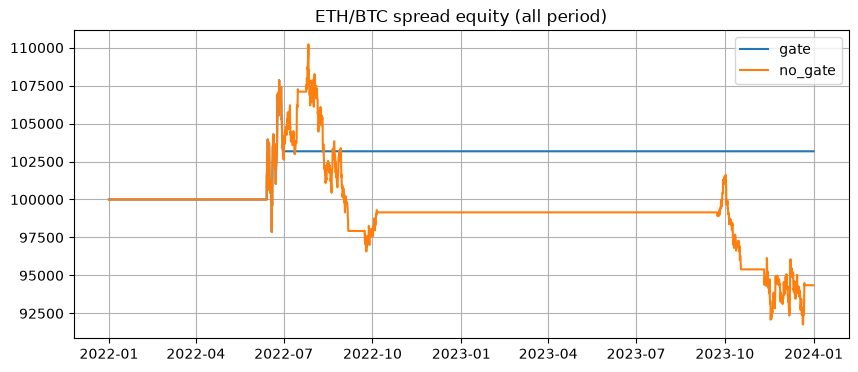

In [23]:
plots.plot_equity(pairs_cmp, ["gate", "no_gate"], ["all"], title="ETH/BTC spread equity ({} period)")

# Final results

Complete BTC and ETH history with the parameters fixed above

Trend and mean-reversion strategies

In [24]:
full_assets = {"BTC": btc, "ETH": eth}
rng = np.random.default_rng(42)
final = {}

for name, df in full_assets.items():
    final[("buy_hold", name)] = compute_buy_hold_benchmark(df, periods=periods, start_capital=start_capital)
    for model_name, model in models.items():
        kw = params.get(model_name, {}).get(name, {})
        final[(model_name, name)] = bactester(df, signals=model(df, **kw), start_capital=start_capital, periods=periods)
    signals = pd.Series(rng.choice([0, -1, 1], size=len(df)), index=df.index)
    final[("random", name)] = bactester(df, signals, start_capital, periods)

pd.DataFrame({k: {m: r[m] for m in keys} for k, r in final.items()}).T.round(3)

,,gross_profit,gross_loss,net_profit,total_return,buy_hold_return,total_trades,win_rate,avg_win,avg_loss,largest_win,largest_loss,avg_holding_days,max_holding_days,max_drawdown,sharpe,sortino
buy_hold,BTC,198464.506,0.000,198464.506,1.985,1.985,1.0,1.000,198464.506,0.000,198464.506,0.000,1826.000,1826.000,-0.770,0.665,0.950
mean_reversion,BTC,185885.183,-280317.900,-94432.716,-0.944,1.985,946.0,0.437,450.085,-525.925,14945.109,-10987.555,0.282,2.000,-0.962,-2.229,-3.006
ma_crossover,BTC,249637.095,-296743.719,-47106.625,-0.471,1.985,261.0,0.372,2573.578,-1809.413,16256.687,-9268.664,3.509,20.333,-0.652,-0.061,-0.087
ma_crossover_v2,BTC,402945.826,-448049.874,-45104.048,-0.451,1.985,149.0,0.383,7069.225,-4870.107,34765.515,-18488.184,11.047,39.500,-0.707,0.057,0.081
ma_cross_long,BTC,429608.333,-346419.903,83188.430,0.832,1.985,68.0,0.294,21480.417,-7217.081,73374.687,-29614.728,11.610,59.167,-0.538,0.520,0.754
random,BTC,148909.020,-248909.011,-99999.991,-1.000,1.985,4878.0,0.335,91.132,-76.729,6438.768,-12640.526,0.247,1.333,-1.000,-6.505,-8.432
buy_hold,ETH,297778.322,0.000,297778.322,2.978,2.978,1.0,1.000,297778.322,0.000,297778.322,0.000,1826.000,1826.000,-0.811,0.745,1.057
mean_reversion,ETH,312137.719,-408073.706,-95935.987,-0.959,2.978,929.0,0.468,717.558,-826.060,11001.026,-11619.494,0.288,1.667,-0.974,-1.718,-2.296
ma_crossover,ETH,891686.334,-850860.514,40825.820,0.408,2.978,248.0,0.407,8828.578,-5788.167,59075.792,-41932.217,3.648,22.167,-0.690,0.414,0.598
ma_crossover_v2,ETH,1162540.454,-992848.334,169692.120,1.697,2.978,104.0,0.404,27679.535,-16013.683,156424.669,-47715.850,16.152,73.333,-0.789,0.638,0.911


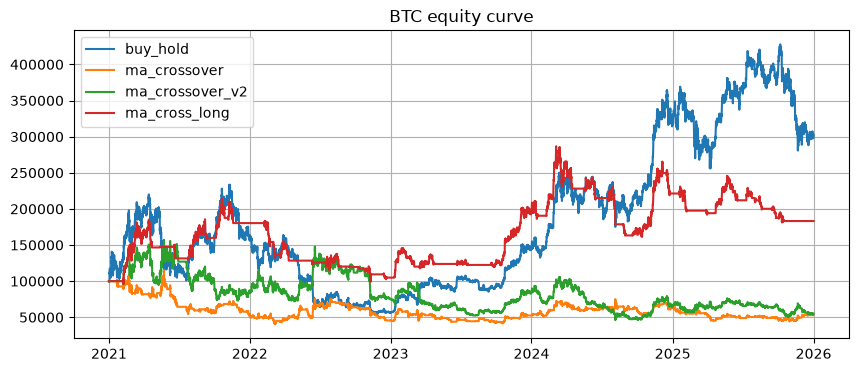

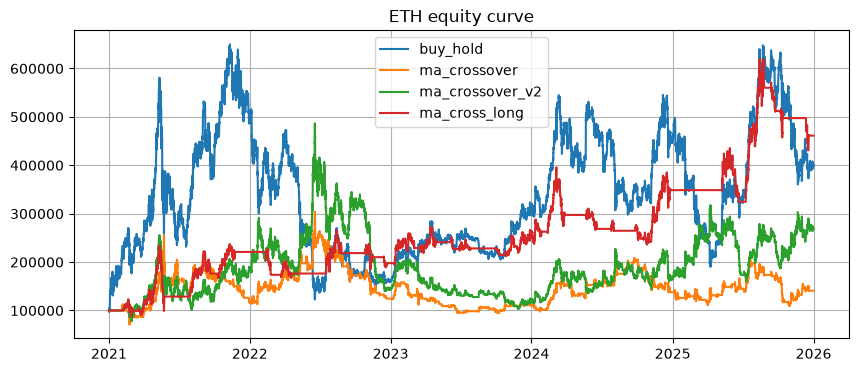

In [25]:
plots.plot_equity(final, ["buy_hold", "ma_crossover", "ma_crossover_v2", "ma_cross_long"], full_assets)

GARCH sizing (from 2023-01-01)

Sliced from `start` because the garch strategies are flat before `test_start`.

In [26]:
garch_final = {}

for name, df in full_assets.items():
    kw = params["ma_cross_long"][name]
    d = df.loc[start:]
    garch_final[("buy_hold", name)] = compute_buy_hold_benchmark(d, periods=periods, start_capital=start_capital)
    for label, fn in garch_models:
        garch_final[(label, name)] = bactester(d, fn(df, **kw).loc[start:], start_capital=start_capital, periods=periods)

pd.DataFrame({k: {m: r[m] for m in keys} for k, r in garch_final.items()}).T.round(3)

,,gross_profit,gross_loss,net_profit,total_return,buy_hold_return,total_trades,win_rate,avg_win,avg_loss,largest_win,largest_loss,avg_holding_days,max_holding_days,max_drawdown,sharpe,sortino
buy_hold,BTC,428551.506,0.000,428551.506,4.286,4.286,1.0,1.000,428551.506,0.000,428551.506,0.000,1096.000,1096.000,-0.344,1.431,2.081
plain,BTC,291753.704,-217015.988,74737.716,0.747,4.286,43.0,0.279,24312.809,-7000.516,69989.819,-28248.563,12.519,59.167,-0.437,0.750,1.076
garch,BTC,284223.870,-213697.464,70526.406,0.705,4.286,43.0,0.279,23685.323,-6893.467,68685.927,-27254.683,12.519,59.167,-0.447,0.730,1.045
garch_v2,BTC,352627.955,-285748.866,66879.089,0.669,4.286,91.0,0.407,9530.485,-5291.646,33429.876,-18576.478,5.234,31.000,-0.340,0.755,1.107
buy_hold,ETH,148126.738,0.000,148126.738,1.481,1.481,1.0,1.000,148126.738,0.000,148126.738,0.000,1096.000,1096.000,-0.651,0.800,1.132
plain,ETH,332259.976,-199031.009,133228.967,1.332,1.481,45.0,0.422,17487.367,-7655.039,58008.260,-33682.116,10.544,33.667,-0.404,0.924,1.339
garch,ETH,312803.986,-197091.251,115712.735,1.157,1.481,45.0,0.400,17377.999,-7299.676,55427.215,-31649.204,10.544,33.667,-0.406,0.866,1.246
garch_v2,ETH,296956.086,-240833.275,56122.811,0.561,1.481,72.0,0.361,11421.388,-5235.506,53355.106,-15589.337,5.736,31.333,-0.389,0.603,0.864


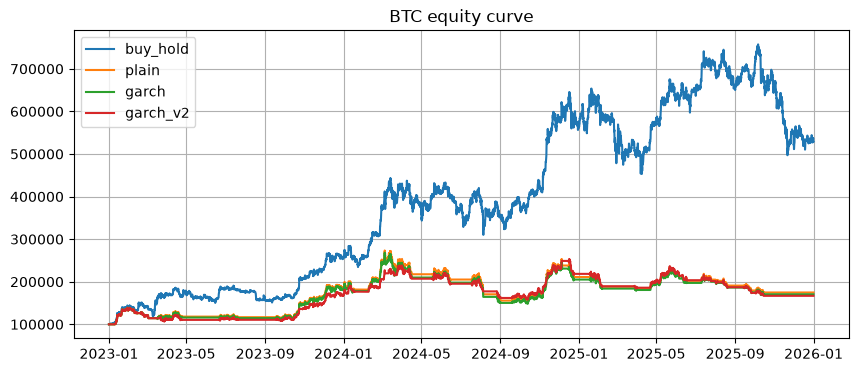

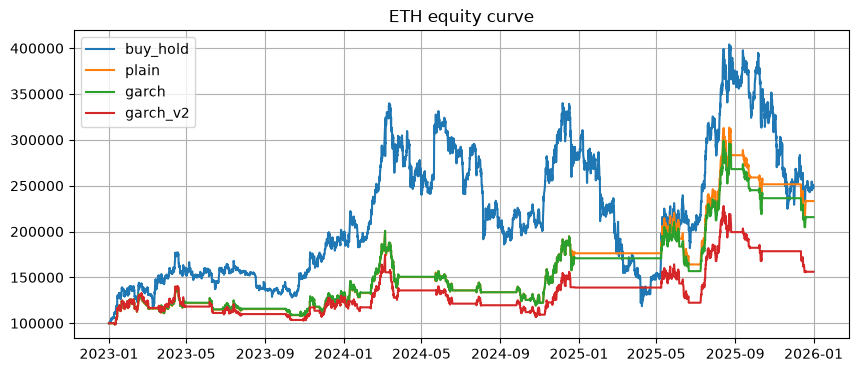

In [27]:
plots.plot_equity(garch_final, ["buy_hold", "plain", "garch", "garch_v2"], full_assets)

ETH/BTC pairs (from 2022-01-01)

In [28]:
pairs_final = {}

for label, p_max in pairs_gates:
    fit = strategies.pairs_fit(eth, btc, p_max=p_max)
    sig = strategies.pairs_reversion(eth, btc, fit=fit)
    spread = strategies.pairs_spread(eth, btc, fit[1])
    print(label, "gate on:", fit[2].loc['2022-01-01':].mean())
    pairs_final[(label, "all")] = bactester(spread.loc['2022-01-01':], sig.loc['2022-01-01':], start_capital=start_capital, periods=periods)

pd.DataFrame({k: {m: r[m] for m in keys} for k, r in pairs_final.items()}).T.round(3)

gate gate on: 0.12320328542094455
no_gate gate on: 1.0


,,gross_profit,gross_loss,net_profit,total_return,buy_hold_return,total_trades,win_rate,avg_win,avg_loss,largest_win,largest_loss,avg_holding_days,max_holding_days,max_drawdown,sharpe,sortino
gate,all,3175.261,0.000,3175.261,0.032,0.127,1.0,1.000,3175.261,0.000,3175.261,0.00,16.667,16.667,-0.059,0.215,0.345
no_gate,all,26138.544,-41812.142,-15673.598,-0.157,0.127,12.0,0.333,6534.636,-5226.518,12332.249,-12367.31,42.403,142.333,-0.375,-0.126,-0.176


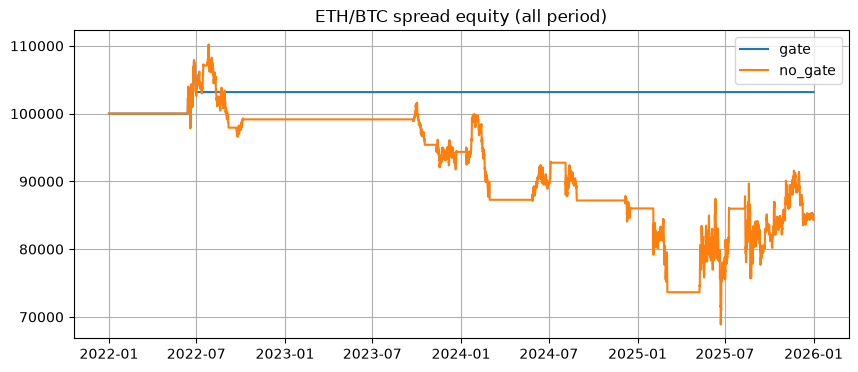

In [29]:
plots.plot_equity(pairs_final, ["gate", "no_gate"], ["all"], title="ETH/BTC spread equity ({} period)")

In [30]:
def quarterly(r):
    return (1 + r).groupby(r.index.tz_localize(None).to_period("Q")).prod() - 1


def beat_table(res, names, start=None):
    rows = {}
    for a in ["BTC", "ETH"]:
        bh = quarterly(res[("buy_hold", a)]["returns"])
        for m in names:
            d = (quarterly(res[(m, a)]["returns"]) - bh).loc[start:]
            rows[(m, a)] = {"quarters": len(d), "beat": int((d > 0).sum()),
                            "beat_pct": (d > 0).mean(), "avg_excess": d.mean()}
    return pd.DataFrame(rows).T.round(3)


names = list(models)
print("2021-23 (tuning period)")
print(beat_table(results, names))
print("2021-25 (full)")
print(beat_table(final, names))
print("2024-25 (out of sample)")
print(beat_table(final, names, start="2024"))

2021-23 (tuning period)
                     quarters  beat  beat_pct  avg_excess
mean_reversion  BTC      12.0   2.0     0.167      -0.250
ma_crossover    BTC      12.0   3.0     0.250      -0.149
ma_crossover_v2 BTC      12.0   3.0     0.250      -0.099
ma_cross_long   BTC      12.0   6.0     0.500      -0.028
mean_reversion  ETH      12.0   4.0     0.333      -0.320
ma_crossover    ETH      12.0   4.0     0.333      -0.151
ma_crossover_v2 ETH      12.0   4.0     0.333      -0.138
ma_cross_long   ETH      12.0   5.0     0.417      -0.116
2021-25 (full)
                     quarters  beat  beat_pct  avg_excess
mean_reversion  BTC      20.0   3.0      0.15      -0.251
ma_crossover    BTC      20.0   4.0      0.20      -0.139
ma_crossover_v2 BTC      20.0   5.0      0.25      -0.123
ma_cross_long   BTC      20.0   7.0      0.35      -0.064
mean_reversion  ETH      20.0   6.0      0.30      -0.302
ma_crossover    ETH      20.0   8.0      0.40      -0.111
ma_crossover_v2 ETH      20.0   7

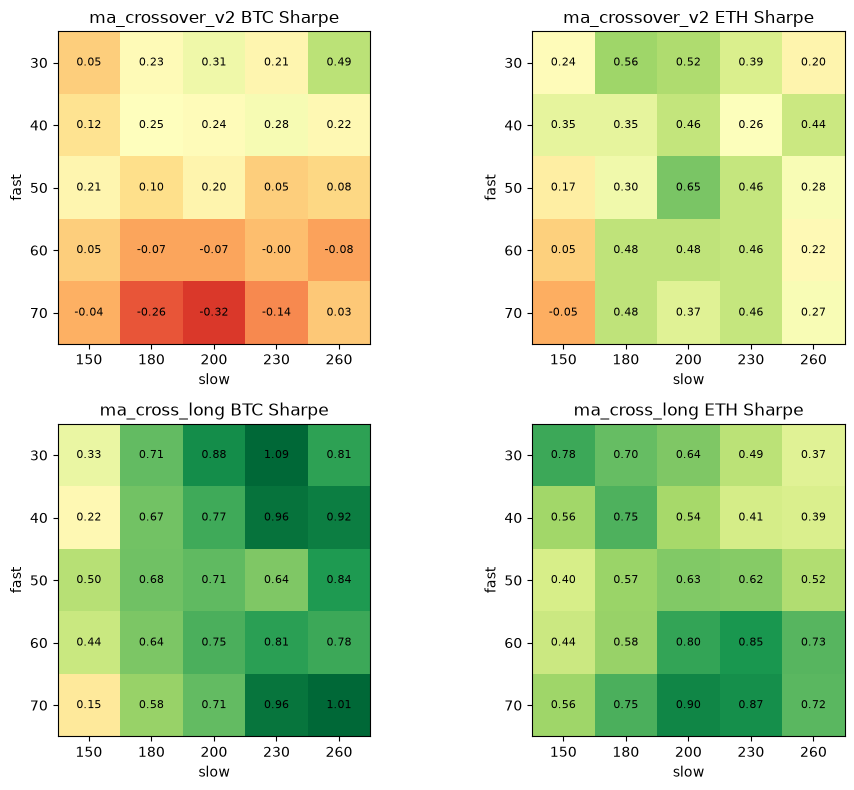

In [31]:
fasts = [30, 40, 50, 60, 70]
slows = [150, 180, 200, 230, 260]
grid_models = {"ma_crossover_v2": strategies.ma_crossover_better,
               "ma_cross_long": strategies.ma_cross_long}


def sharpe_grid(model_name, model, name, df):
    out = pd.DataFrame(index=fasts, columns=slows, dtype=float)
    for f in fasts:
        for s in slows:
            kw = {**params[model_name][name], "fast": f, "slow": s}
            out.loc[f, s] = bactester(df, model(df, **kw), start_capital, periods)["sharpe"]
    return out


grids = {(m, n): sharpe_grid(m, fn, n, df)
         for m, fn in grid_models.items() for n, df in assets.items()}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, ((m, n), g) in zip(axes.flat, grids.items()):
    ax.imshow(g.values, cmap="RdYlGn", vmin=-0.5, vmax=1.0)
    ax.set_xticks(range(len(slows)), slows)
    ax.set_yticks(range(len(fasts)), fasts)
    ax.set_title(f"{m} {n} Sharpe")
    ax.set_xlabel("slow")
    ax.set_ylabel("fast")
    for i in range(len(fasts)):
        for j in range(len(slows)):
            ax.text(j, i, f"{g.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [32]:
pd.DataFrame({k: {"min": g.values.min(), "median": np.median(g.values),
                  "max": g.values.max(), "share_positive": (g.values > 0).mean()}
              for k, g in grids.items()}).T.round(3)

min  median    max  share_positive
ma_crossover_v2 BTC -0.324   0.077  0.489            0.68
                ETH -0.048   0.368  0.649            0.96
ma_cross_long   BTC  0.149   0.712  1.087            1.00
                ETH  0.369   0.621  0.904            1.00